# Join Plasma Olink Data With HISE Descriptors

In [1]:
## Load Libraries installed from 'add_R_packages.txt'
library(hise)
library(magrittr)
library(tidyverse)
library(readxl)
library(naniar)
library(visdat)
library(janitor)
library(skimr)
library(ggridges)
library(ggpubr)
library(broom)
library(car)
library(gt)
library(gtExtras)
library(gtsummary)
library(knitr)  
library(logger)
library(OlinkAnalyze)
library(devtools)
suppressPackageStartupMessages(library(ComplexHeatmap))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract()   masks magrittr::extract()
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::lag()       masks stats::lag()
✖ purrr::set_names() masks magrittr::set_names()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test



Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is 

In [2]:
### that were custom made for this project
source('../00-utilities/functions/00_functions_data_loading.R')
file.sources <- list.files(
    path = "./ndmmFH1_helper_functions", 
    pattern = "\\.R$", full.names = TRUE
)
file.sources
# Source each R file
invisible(sapply(file.sources, source))

Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose




[1] "./ndmmFH1_helper_functions/data_crud.R" 
[2] "./ndmmFH1_helper_functions/data_manip.R"
[3] "./ndmmFH1_helper_functions/data_vis.R"  
[4] "./ndmmFH1_helper_functions/misc.R"      
[5] "./ndmmFH1_helper_functions/static.R"

## Description

In this file the csv files generated from the cleaning of the bridged plasma samples and the bone marrow data is loaded. All descriptors from hise for 'olink' as filetype is loaded and the metadata in hises is retrieved by means of the sampleKitGuid in the data files. 

BM samples do not have a sampleKitGuid but only a sampleID. Checking all sampleIDs across all columns in the descriptor set does not give any match, leading the conclusion that it is not a matter of simply differently named identifiers. 

The plasma olink data had some more sampleKitGuids than was present in the hise descriptor data. Many of the samples do not have a match 


Pull file descriptrs and load the csv file with cleaned and combine plasma sample olink data. 

In [3]:
data.olink.bm.samples <- readCSVFiles("../../data/olink/Olink_BM_with_hise_descriptors_08-18-2025.csv") %>% pluck(1)
data.olink.plasma.samples <- readCSVFiles("../../data/olink/Combined_Olink_plasma_samples_09-02-2025.csv") %>% pluck(1)

Rows: 211896 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (19): SampleID, OlinkID, UniProt, Assay, Panel, QC_Warning, Normalizatio...
dbl  (5): MissingFreq, LOD, NPX, DaysSinceFirstVisit, Age
lgl  (1): is_technical_control

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 4039727 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): SampleID, OlinkID, UniProt, Assay, Panel, PlateID, Normalization, ...
dbl  (5): Index, BatchOffset, NPX, LOD, BatchID
lgl  (1): is_control_sample

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
dim(data.olink.bm.samples)
dim(data.olink.plasma.samples)

[1] 211896     25

[1] 4039727      21

In [5]:
fh1_descriptors.lists <- hise::getFileDescriptors(fileType = "Olink",
                                                    filter=list("cohort.cohortGuid"=c('FH1')),
                                                    toDF = TRUE)
fh2_descriptors.lists <- hise::getFileDescriptors(fileType = "Olink",
                                                    filter=list("cohort.cohortGuid"=c('FH2')),
                                                    toDF = TRUE)
br1_descriptors.lists <- hise::getFileDescriptors(fileType = "Olink",
                                                    filter=list("cohort.cohortGuid"=c('BR1')),
                                                    toDF = TRUE)
br2_descriptors.lists <- hise::getFileDescriptors(fileType = "Olink",
                                                    filter=list("cohort.cohortGuid"=c('BR2')),
                                                    toDF = TRUE)

In [44]:
olink.descriptors.df <- rbind(fh1_descriptors.lists$descriptors,
                              fh2_descriptors.lists$descriptors,
                              br1_descriptors.lists$descriptors,
                              br2_descriptors.lists$descriptors)

In [45]:
table(olink.descriptors.df$cohort.cohortGuid)


BR1 BR2 FH1 FH2 
468 510 435 160 

Comparing columns across descriptors for filetype Olink, the BM data with hise descriptors and metadata from excel and hise and the joined plasma samples, we can see that sample id and samplekitguid is present in all but differently named due to list flattening from hise. 

In [46]:
janitor::compare_df_cols(list(data.olink.plasma.samples, data.olink.bm.samples, olink.descriptors.df)) %>%
  gt() %>% 
  tab_header(title = "Comparison of columns in Plasma Olink Data and Descriptors from HISE") %>% 
  sub_missing() %>% 
  gt:::as.tags.gt_tbl() 

Shiny tags cannot be represented in plain text (need html)

None of the sampleIDs in the BM Olink Data seem to exist in any column in the descriptor data. 

In [47]:
exists <- apply(olink.descriptors.df, 2, \(col) {data.olink.bm.samples[["SampleID"]] %in% col}) %>% apply(2, any)
any(exists)

[1] FALSE

Remove any potential copies of rows among the descriptors. 

In [48]:
olink.descriptors.df <- distinct(olink.descriptors.df)
dim(olink.descriptors.df)

[1] 1573   32

Find duplicates among kitguids

In [49]:
descriptors.dupes <- olink.descriptors.df %>% 
  get_dupes(sample.sampleKitGuid) 

Find which columns are to blame for the duplicates among kitguid. 

In [ ]:
dupes.table.descriptors.all <- blame.dupes(descriptors.dupes, "sample.sampleKitGuid")

Make a frequency table of how common columns are to cause the duplicates for overview

In [51]:
dupes.table.descriptors.all %>% pull(cols_to_blame) %>% unique
table(dupes.table.descriptors.all[["cols_to_blame"]])

[1] "file.id, file.name"                                                                                  
[2] "projectGuid.projectGuid, sample.id, file.id, file.name, subject.id, project.short_name, project.name"


                                                                                  file.id, file.name 
                                                                                                 462 
projectGuid.projectGuid, sample.id, file.id, file.name, subject.id, project.short_name, project.name 
                                                                                                   3 

Looking through the data in hise that have duplicates, we can see that most duplicates pertain to different file names and file id while all other columns are equal, and in some cases sample.id and subject.id is also different for the same sample.sampleKitGuid. 

For the rows where only file and file id is different, it probably does not matter which row is taken as the relevant metadata is identical.

After internal review with Lauren Okada, this is likely a consequence of samples being split across projects apparently. 

## Duplicates in Hise Database

As can be seen from the above tables, the doublets in hise are mostly due to different filenames and file ids for the same kitGuid. This is due to samples ending up in different projects, but the subject guid is still the same. This is also the reason why one duplicate has a different sample id and subject id, as Lauren has explained it to me. Since all columns of interest to us are the same across the duplicated rows, there is no specific reason to pick one over the other.


Select the pertinent columns from hise. 

Map columns in Hise to common names and drop redundant one. 

In [52]:
hise.columns.mapping <- list(
  lastUpdated = NULL,
  sample.id = NULL, #has a doublet, redo if needed later on
  sample.bridgingControl = "sample.bridgingControl",
  sample.sampleKitGuid = "sample.sampleKitGuid",
  sample.visitName = "sample.visitName",
  sample.visitDetails = "sample.visitDetails",
  sample.drawDate = "sample.drawDate",
  sample.daysSinceFirstVisit = "sample.daysSinceFirstVisit",
  sample.diseaseStatesRecordedAtVisit = "sample.diseaseStatesRecordedAtVisit",
  file.id = NULL,
  file.name = NULL,
  file.batchID = NULL, #empty in hise
  file.panel = NULL, #empty in hise
  file.pool = NULL, #empty in hise
  file.fileType = "file.fileType",
  file.majorVersion = NULL, #empty in hise
  subject.id = NULL, #favor subject.subjectguid
  subject.biologicalSex = "subject.biologicalSex",
  subject.birthYear = "subject.birthYear",
  subject.ethnicity = "subject.ethnicity",
  subject.partnerCode = "subject.partnerCode",
  subject.race = "subject.race",
  subject.subjectGuid = "subject.subjectGuid",
  cohort.cohortGuid = "cohort.cohortGuid"
)

In [53]:
descriptors.cut <- column_map(olink.descriptors.df, mapping = hise.columns.mapping)

Having removed several columns, make empty strings and NA equal and remove virtual duplicates of rows again

In [54]:
descriptors.cut <- mutate(
  descriptors.cut,
  across(
    where(is.character),
    ~ if_else(.x == "", NA_character_, .x)
  )
)

descriptors.cut %<>% distinct()

Check duplicates again after having removed extraneous columns and removed duplicate rows. Get duplicates with the same value for sample.sampleKitGuid among descriptors as this will be the joining column. 

In [55]:
descriptors.cut.only.dupes <- get_dupes(descriptors.cut, sample.sampleKitGuid)

In [56]:
table(descriptors.cut.only.dupes$subject.subjectGuid,
      descriptors.cut.only.dupes$sample.visitDetails, useNA='always') %>% t

                           
                            FH1002 <NA>
  MM Post Transplant 1 year      2    0
  <NA>                           0    0

In the table it can be seen that duplicates are FH1002, FH2004, 2007. Since the above table disrupts the rows, we will look further below by looking at which columns cause the duplicates and how they look. FH1002's duplicates are due to being in different projects  

In [ ]:
descriptors.cut.only.dupes[descriptors.cut.only.dupes$subject.subjectGuid=='FH1002',] %>% t

It looks like these samples are likely duplicates due to being assigned into different projects. Given that only one sample of FH1002 is impacted by downstream analyses, so we will include FH1002. 

In [58]:
#descriptors.cut.only.dupes <- descriptors.cut.only.dupes[descriptors.cut.only.dupes$subject.subjectGuid!='FH1002',]
descriptors.cut.wo.dupes_1st <- descriptors.cut.wo.dupes %>% group_by(sample.sampleKitGuid) %>% slice(1)

In [62]:
# left anti_join: A AB B -> A
#> df1 <- tibble(a=c(1,2,3), ID=c(1,2,3))
#> df2 <- tibble(b=c(2,3,4), ID=c(2,3,4))
#> anti_join(df1, df2, by="ID")
## A tibble: 1 × 2
#      a    ID
#  <dbl> <dbl>
#1     1     1
descriptors.cut.wo.dupes <- anti_join(descriptors.cut, descriptors.cut.only.dupes, by = "sample.sampleKitGuid")

paste("Descriptors are", nrow(descriptors.cut), "numbers of rows before anti join")
paste("Descriptors of which are dupes in kitguid", nrow(descriptors.cut.only.dupes))
paste("The resulting amount of rows is consequently:", nrow(descriptors.cut.wo.dupes), "which should be equal to", nrow(descriptors.cut)-nrow(descriptors.cut.only.dupes))

[1] "Descriptors are 1318 numbers of rows before anti join"

[1] "Descriptors of which are dupes in kitguid 2"

[1] "The resulting amount of rows is consequently: 1316 which should be equal to 1316"

Join the Plasma Olink Data with the descriptors less the duplicates on sampleKitGuid for a combined data set of plasma samples with metadata.

In [69]:
data.olink.plasma.joined <- inner_join(data.olink.plasma.samples, 
                                       descriptors.cut.wo.dupes_1st, 
                                       by = join_by(sampleKitGuid == sample.sampleKitGuid),
                                       relationship = "many-to-one")

In [70]:
dim(data.olink.plasma.joined)

[1] 2061417      44

Look at how the cohorts distribute across visits. BR1 and BR2 have Immune Variation 0, 7 and 90 and a Flue Series timepoint. 
FH1 have 5 times more rows for flu visit, but otherwise, as expected, most for myeloma pre=treatment followed samples from after treatment. 

It looks like there is a gap in the data collection, but 60 and 90 days after transplant for FH1 should probably be combined. 

This table also shows that it is safe to only keep the FH1 cohort to not miss any myeloma visits. 

In [71]:
table(data.olink.plasma.joined$sample.visitDetails, data.olink.plasma.joined$cohort.cohortGuid)

                                 
                                     BR1    BR2    FH1    FH2
  Immune Variation Day 0           66225  70656      0      0
  Immune Variation Day 7           66225  70656      0      0
  Immune Variation Day 90          58775  69184      0      0
  MM CD38 12 months                    0      0      0  21732
  MM CD38 18 months                    0      0      0   2580
  MM CD38 2 weeks                      0      0      0  19820
  MM CD38 4 months                     0      0      0  24631
  MM CD38 4 weeks                      0      0      0  16861
  MM CD38 6 months                     0      0      0  23204
  MM CD38 6 weeks                      0      0      0  13947
  MM CD38 8 weeks                      0      0      0  15055
  MM CD38 9 months                     0      0      0  23189
  MM CD38 Pre-treatment                0      0      0  22415
  MM CD38 Progression                  0      0      0   5160
  MM End Induction 1st Draw         

## Overview the resulting data

Filter for FH1, BR1 and BR2

In [72]:
data.olink.plasma.joined.target_cohorts <- data.olink.plasma.joined %>% filter(cohort.cohortGuid %in% c("FH1", "BR1", "BR2"))

Fix the datetime column for better export to csv

In [73]:
data.olink.plasma.joined.target_cohorts %<>% mutate(sample.drawDate = lubridate::as_datetime(sample.drawDate))

In [75]:
column_mapping <- list(
    file.filetype = NULL, #constant
    cohort.cohortGuid = "Cohort",
    subject.subjectGuid = "Subject",
    subject.race = "Race",
    subject.partnerCode = NULL, #Only need to know cohort
    subject.ethnicity = "Ethnicity",
    subject.birthYear = "birthYear",
    subject.biologicalSex = "Sex",
    sample.diseaseStatesRecordedAtVisit = "diseaseStatesRecordedAtVisit",
    sample.drawDate = "drawDate",
    sample.visitDetails = "visitDetails",
    sample.visitName = "visitName",
    is_control_sample = NULL, #constant, no TRUE
    SampleWarningBridge = "sampleWarningBridge",
    sample.bridgingControl = "is_bridgingControl",
    submission_ref = NULL, #incomplete,
    sample.daysSinceFirstVisit = "daysSinceFirstVisit"
)

In [76]:
data.olink.plasma.joined.target_cohorts <- column_map(df = data.olink.plasma.joined.target_cohorts, 
                    mapping = column_mapping, 
                    delete.missing = FALSE)

__NOTE__ Panel_Lot_Nr is missing

In [77]:
data.olink.plasma.joined.target_cohorts %<>%
  mutate(
      sampleWarningBride = as.factor(sampleWarningBridge),
      daysSinceFirstVisit = as.numeric(daysSinceFirstVisit),
      Subject = as.factor(Subject),
      Race = as.factor(Race),
      Cohort = as.factor(Cohort),
      Sex = as.factor(Sex),
      diseaseStatesRecordedAtVisit = as.factor(diseaseStatesRecordedAtVisit),
      BatchID = as.factor(BatchID),
      PlateID = as.factor(PlateID),
      is_bridgingControl = case_when(
        tolower(is_bridgingControl) == "true"  ~ TRUE,
        tolower(is_bridgingControl) == "false" ~ FALSE,
        TRUE                                   ~ NA_real_ # Handle NA and any other case#
        ),
      # Panel_Lot_Nr = as.factor(Panel_Lot_Nr),
      N_Bridge = as.factor(N_Bridge),
      drawDate = format(drawDate, "%Y-%m-%d") 
  ) %>%
  unite(AssayUnique, Assay, OlinkID, sep = ".", remove = FALSE)

## Data Missingness

,SampleID,Index,AssayUnique,OlinkID,UniProt,Assay,Panel,PlateID,Normalization,Assay_Warning,⋯,BatchOffset,NPX,LOD,sampleWarningBridge,sampleWarningBride,diseaseStatesRecordedAtVisit,lab.id,lab.revisionNumber,lab.sampleKitGuid,
27501,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,0,1
130669,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,0,3
48283,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,0,1,1,0,2
819944,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,0,0,0,0,4
11776,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,1,0,0,0,5
29440,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,1,1,0,4
602048,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,0,0,0,6
13,1,1,1,1,1,1,1,1,1,1,⋯,1,1,0,1,1,1,1,1,0,2
29,1,1,1,1,1,1,1,1,1,1,⋯,1,1,0,1,1,1,0,0,0,4
2,1,1,1,1,1,1,1,1,1,1,⋯,1,1,0,1,1,0,0,0,0,5


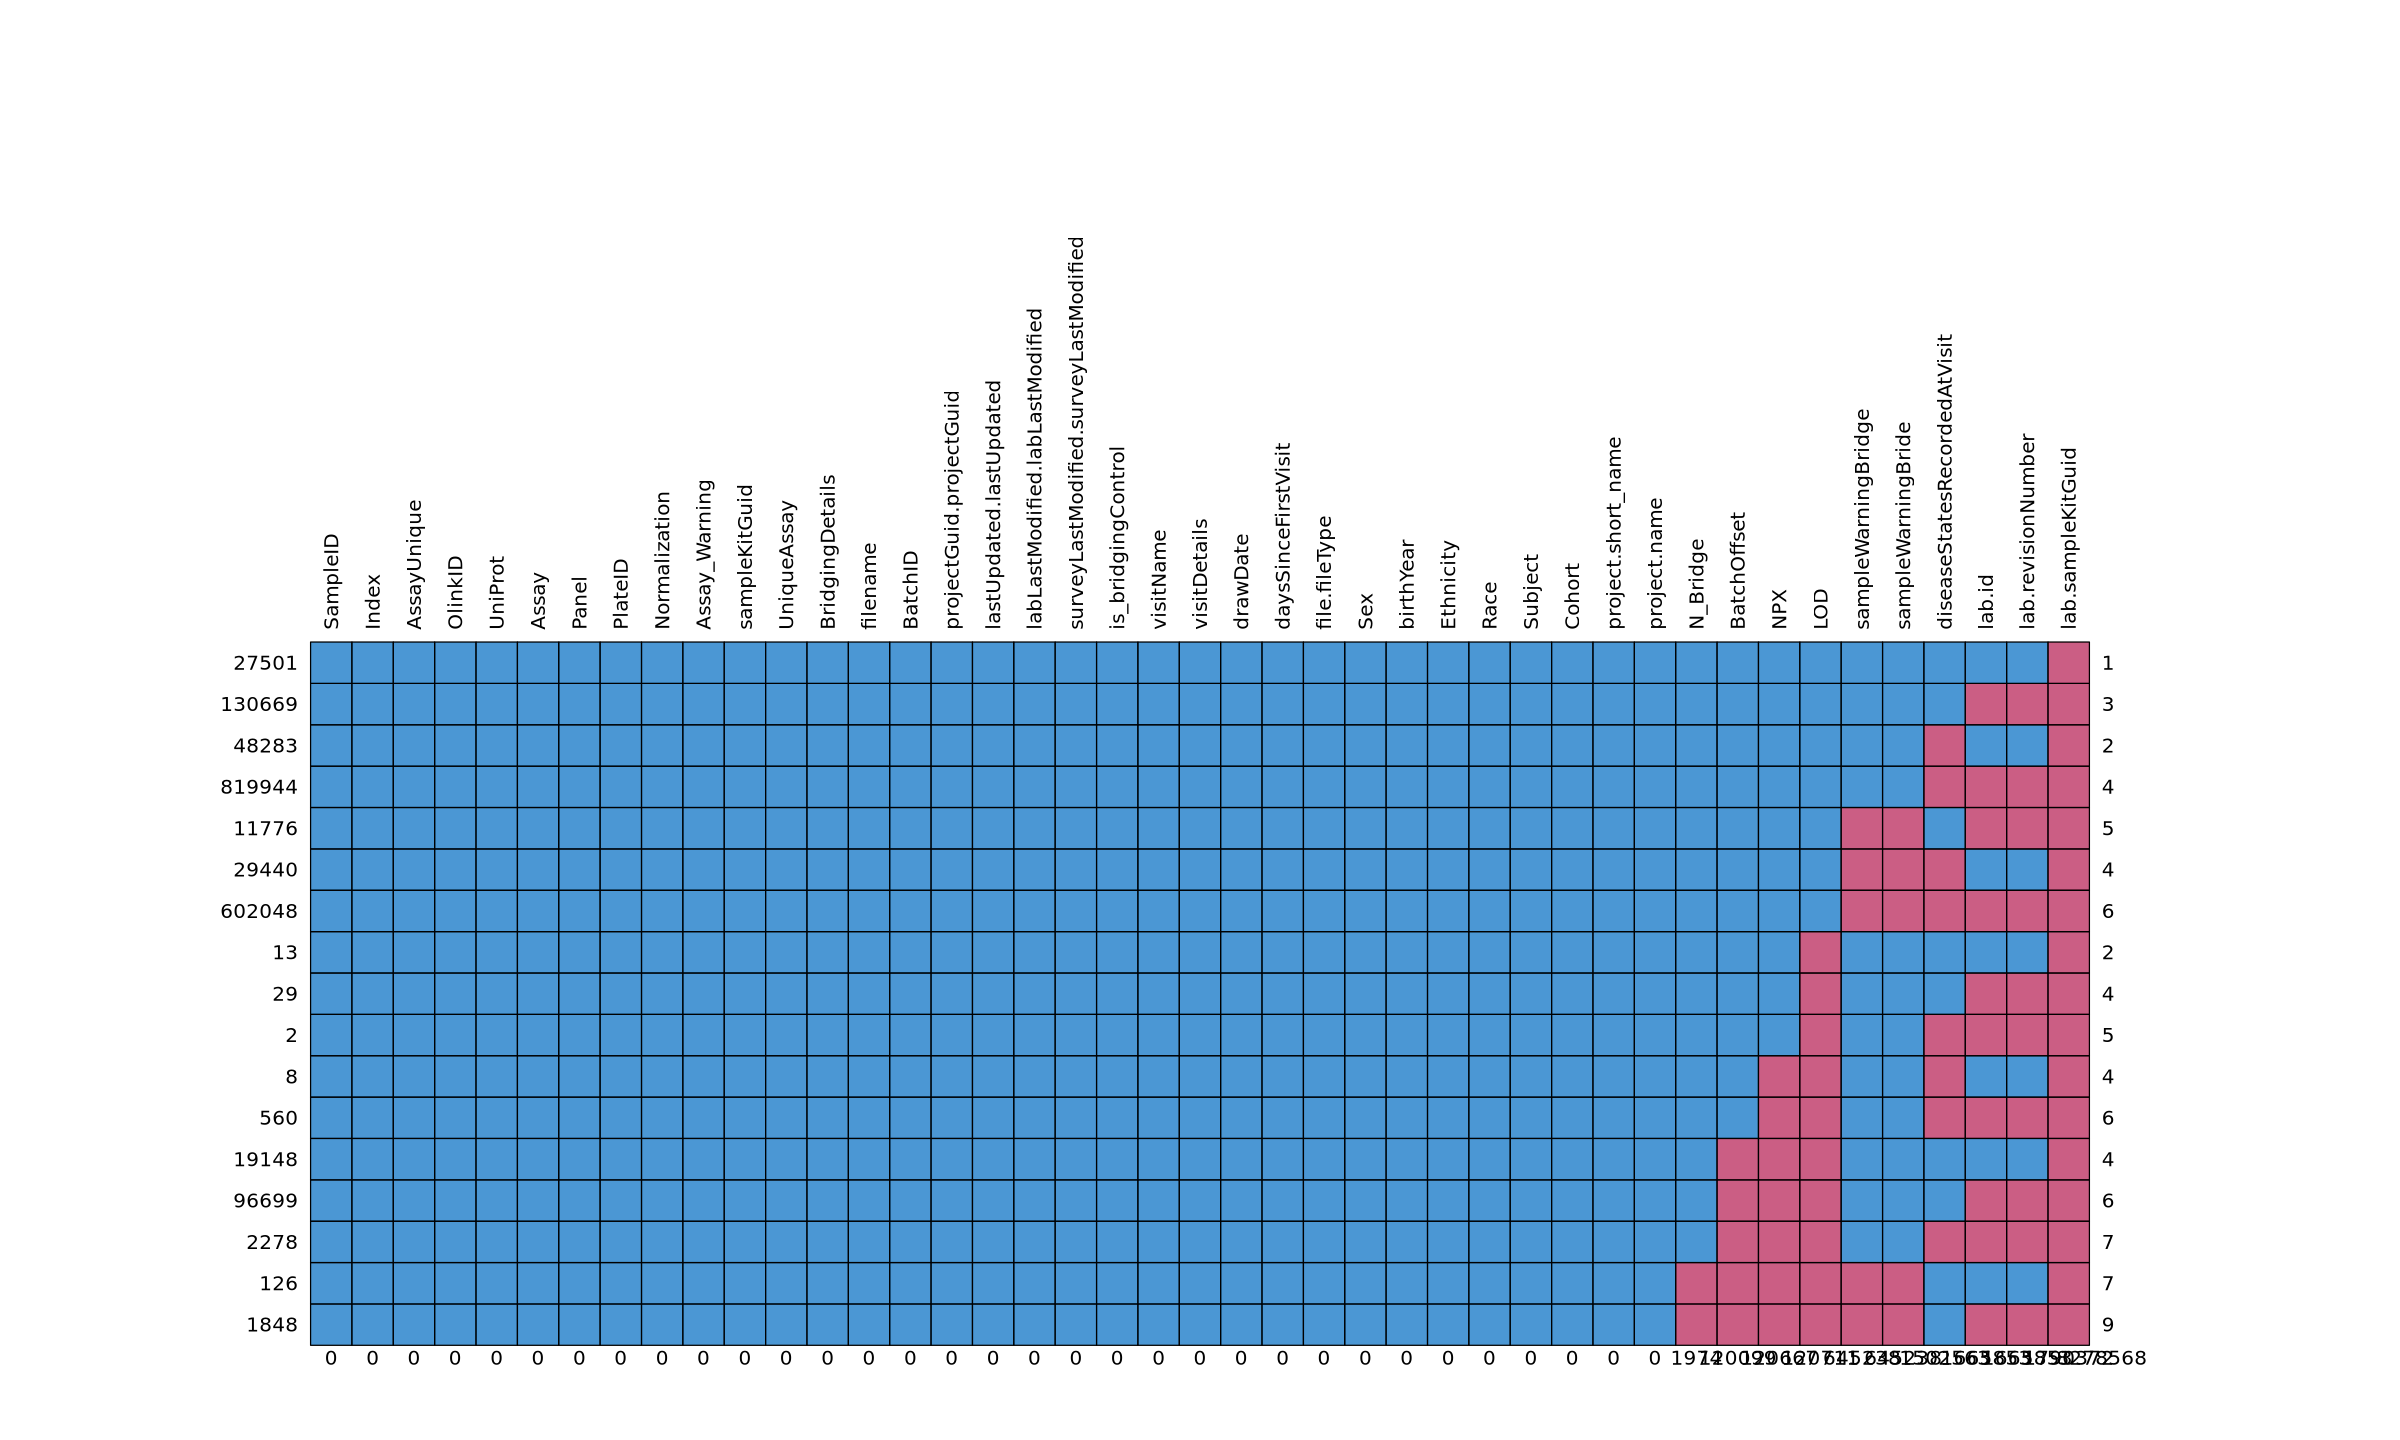

In [78]:
options(repr.plot.width = 20, repr.plot.height = 12)
data.olink.plasma.joined.target_cohorts %>% 
  mice::md.pattern(plot=TRUE, rotate.names = T)

# Write data

In [79]:
file.name.csv <- "Olink_Plasma_FH1_BR1_BR2_with_hise_descriptors.csv"
file.olink.path <- file.path("../Data", file.name.csv)
write.csv(data.olink.plasma.joined.target_cohorts, file.olink.path)

In [35]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] patchwork_1.2.0       data.table_1.17.8     ComplexHeatmap_2.18.0
 [4] devtools_2.4.5        usethis_3.0.0         OlinkAnalyze_4.3.1   
 [7] logger_0.4.0          knitr_1.50            gtsummary_2.3.0      
[10] gtExtras_0.6.0        gt_1.0.0              car_3.1-2            
[13] carData_3.0